# Translation to Strategy: The Central Conversion Story

**Docker image**: `ml4t`

The IC-to-Sharpe gap is the central narrative of Ch16-20. Ch16 introduced
the concept with individual examples; this notebook shows the **full 9-CS
picture including holdout**. It also covers entry/cadence/horizon effects
and selectivity — the IC-to-Sharpe translation story (allocator choice
is taken up in §05).

This is one of the few analyses that appears in both Ch16 (introduction)
and Ch20 (full picture with holdout). The framing: **IC translates into
Sharpe only through implementation.**

**Learning Objectives**:
- See the full IC-to-Sharpe translation across 9 case studies
- Compare validation and holdout Sharpe (does the translation persist?)
- Understand which implementation factors mediate conversion

**Book Reference**: Chapter 20, Section 20.3 (Translation to Strategy)

**Prerequisites**: Run [`01_aggregate_synthesis`](01_aggregate_synthesis.ipynb) first.

In [1]:
"""Ch20 Translation to Strategy — IC-to-Sharpe gap with holdout closure."""

import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")

from utils.paths import get_chapter_dir

In [2]:
MAX_SYMBOLS = 0

In [3]:
OUTPUT_DIR = get_chapter_dir(20) / "output"

DISPLAY_NAMES = {
    "etfs": "ETFs",
    "crypto_perps_funding": "Crypto",
    "nasdaq100_microstructure": "NASDAQ-100",
    "sp500_equity_option_analytics": "S&P 500 Eq+Opt",
    "us_firm_characteristics": "US Firms",
    "fx_pairs": "FX Pairs",
    "cme_futures": "CME Futures",
    "sp500_options": "S&P 500 Options",
    "us_equities_panel": "US Equities",
}

## Load Data

In [4]:
variant_df = pl.read_parquet(OUTPUT_DIR / "variant_analysis.parquet")
bt_df = pl.read_parquet(OUTPUT_DIR / "backtest_comparison.parquet")
synthesis = json.load((OUTPUT_DIR / "all_synthesis.json").open())

sweep_path = OUTPUT_DIR / "signal_sweep.parquet"
sweep_df = pl.read_parquet(sweep_path) if sweep_path.exists() else pl.DataFrame()

print(f"Variants: {len(variant_df)} across {variant_df['case_study'].n_unique()} case studies")
if len(sweep_df) > 0:
    print(
        f"Signal sweep: {len(sweep_df)} entries across {sweep_df['case_study'].n_unique()} case studies"
    )

Variants: 423 across 9 case studies


## IC vs Sharpe: Validation and Holdout Overlay

This is the key figure that differentiates NB03 from Ch16. Ch16 shows
validation-only IC-to-Sharpe with mechanical annotations (cadence, entry
rules, turnover). This notebook shows the **validation vs holdout overlay**:
does the translation pattern hold out-of-sample?

In [5]:
# Load holdout results for overlay
holdout_parquet = OUTPUT_DIR / "holdout_results.parquet"
holdout_map = {}
if holdout_parquet.exists():
    _ho_df = pl.read_parquet(holdout_parquet)
    holdout_map = {row["cs_id"]: row for row in _ho_df.iter_rows(named=True)}

In [6]:
# Build validation scatter from synthesis data (rank-1 configuration per CS)
val_points = []
ho_points = []
for cs, data in synthesis.items():
    models = data["pipeline_summary"]["models"]
    backtest = data["pipeline_summary"].get("backtest", {})
    costs = data["pipeline_summary"].get("costs", {})
    best_ic = max((m.get("ic_mean") or 0) for m in models.values()) if models else 0
    val_sharpe = costs.get("net_sharpe_at_actual")

    if best_ic and val_sharpe is not None:
        val_points.append(
            {
                "case_study": DISPLAY_NAMES.get(cs, cs),
                "ic": best_ic,
                "sharpe": val_sharpe,
                "split": "Validation",
            }
        )

    # Holdout point
    ho = holdout_map.get(cs, {})
    ho_ic = ho.get("holdout_ic")
    ho_sharpe = ho.get("holdout_sharpe")
    if ho_ic is not None and ho_sharpe is not None:
        ho_points.append(
            {
                "case_study": DISPLAY_NAMES.get(cs, cs),
                "ic": ho_ic,
                "sharpe": ho_sharpe,
                "split": "Holdout",
            }
        )

scatter_data = pl.DataFrame(val_points + ho_points)

In [7]:
def plot_ic_vs_sharpe():
    """Plot IC vs Sharpe scatter with validation/holdout overlay."""
    if scatter_data.height > 3:
        fig, ax = plt.subplots(figsize=(10, 7))

        scatter_pd = scatter_data.to_pandas()
        case_studies = scatter_pd["case_study"].unique()
        palette = plt.cm.tab10(np.linspace(0, 1, len(case_studies)))
        cs_colors = dict(zip(case_studies, palette, strict=False))

        # Validation points (filled circles)
        val_data = scatter_pd[scatter_pd["split"] == "Validation"]
        for cs in case_studies:
            mask = val_data["case_study"] == cs
            if mask.any():
                ax.scatter(
                    val_data.loc[mask, "ic"],
                    val_data.loc[mask, "sharpe"],
                    c=[cs_colors[cs]],
                    label=f"{cs} (val)",
                    s=80,
                    alpha=0.8,
                    marker="o",
                    edgecolors="white",
                    linewidth=0.5,
                )

        # Holdout points (diamond markers, same colors)
        ho_data = scatter_pd[scatter_pd["split"] == "Holdout"]
        for cs in case_studies:
            mask = ho_data["case_study"] == cs
            if mask.any():
                ax.scatter(
                    ho_data.loc[mask, "ic"],
                    ho_data.loc[mask, "sharpe"],
                    c=[cs_colors[cs]],
                    label=f"{cs} (holdout)",
                    s=100,
                    alpha=0.9,
                    marker="D",
                    edgecolors="black",
                    linewidth=0.8,
                )

        # Connect validation → holdout with arrows for each CS
        for cs in case_studies:
            v = val_data[val_data["case_study"] == cs]
            h = ho_data[ho_data["case_study"] == cs]
            if len(v) == 1 and len(h) == 1:
                ax.annotate(
                    "",
                    xy=(h["ic"].iloc[0], h["sharpe"].iloc[0]),
                    xytext=(v["ic"].iloc[0], v["sharpe"].iloc[0]),
                    arrowprops=dict(arrowstyle="->", color=cs_colors[cs], alpha=0.4, lw=1),
                )

        ax.axhline(y=0, color="gray", linestyle="--", alpha=0.3)
        ax.axvline(x=0, color="gray", linestyle="--", alpha=0.3)
        ax.set_xlabel("IC (Rank Correlation)")
        ax.set_ylabel("Sharpe Ratio (Annualized)")
        ax.set_title("IC → Sharpe Translation: Validation vs Holdout")
        ax.legend(fontsize=7, loc="lower right", ncol=2)
        fig.tight_layout()
        fig.show()
    else:
        print("Insufficient data for IC-vs-Sharpe scatter")

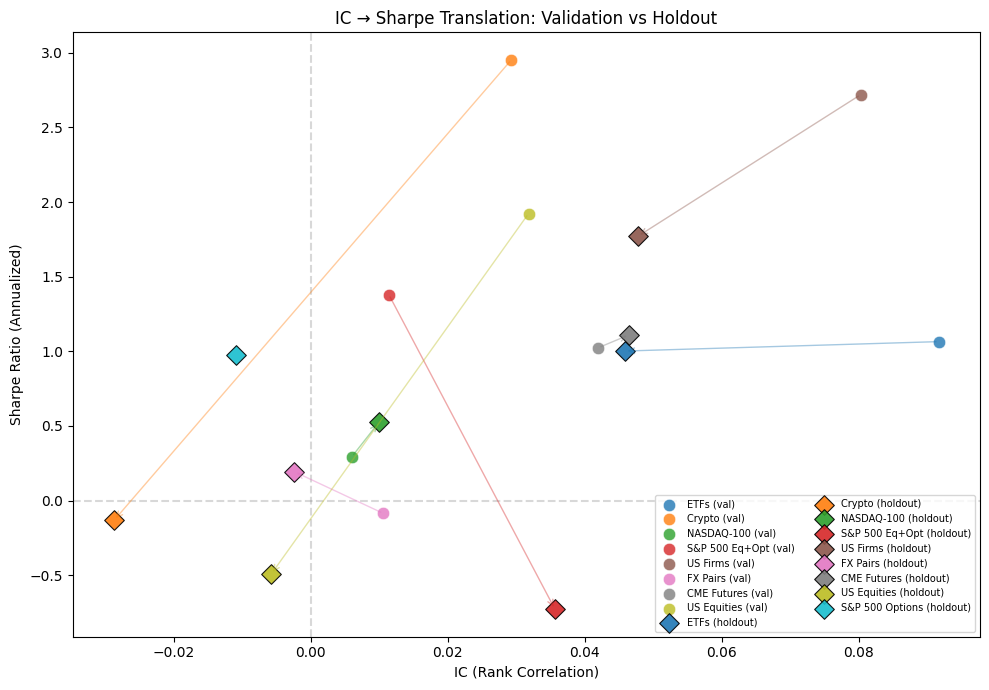

In [8]:
plot_ic_vs_sharpe()

The arrows show how each case study moves from validation (circles) to
holdout (diamonds). Strategies where the arrow points down-left show
holdout degradation — both IC and Sharpe decline. Strategies where the
arrow stays flat or points right show robust translation. This is the
closure question Ch16 cannot answer with validation data alone.

## Where the IC-leading and Sharpe-leading families diverge

Across the nine case studies, **the model family with the highest mean IC
is rarely the same family that produces the highest backtest Sharpe**.
This IC-Sharpe gap reflects how implementation details (entry scheme,
position sizing, rebalancing frequency) mediate the conversion from
prediction quality to portfolio performance.

In [9]:
# Build family-level comparison: IC leader vs Sharpe leader per case study
leader_rows = []
for cs, data in synthesis.items():
    models = data["pipeline_summary"]["models"]
    backtest = data["pipeline_summary"].get("backtest", {})

    # IC leader: model family with highest mean IC
    best_ic_family = None
    best_ic_val = -1
    for family, info in models.items():
        ic = info.get("ic_mean") or 0
        if ic > best_ic_val:
            best_ic_val = ic
            best_ic_family = family

    # Sharpe leader: extract family from best_source (e.g., "tabular_dl/tabm_l")
    best_source = backtest.get("best_source", "")
    sharpe_leader = best_source.split("/")[0] if best_source else ""
    val_sharpe = backtest.get("ml_sharpe", 0)

    ho = holdout_map.get(cs, {})
    ho_sharpe = ho.get("holdout_sharpe")

    leader_rows.append(
        {
            "Case Study": DISPLAY_NAMES.get(cs, cs),
            "IC Leader": best_ic_family or "—",
            "IC": round(best_ic_val, 3) if best_ic_val > 0 else "—",
            "Sharpe Leader": sharpe_leader or "—",
            "Val Sharpe": round(val_sharpe, 3) if val_sharpe else "—",
            "HO Sharpe": round(ho_sharpe, 3) if ho_sharpe is not None else "—",
            "Same?": "Yes" if best_ic_family == sharpe_leader else "No",
        }
    )

if leader_rows:
    leader_df = pl.DataFrame(leader_rows)
    mismatches = sum(1 for r in leader_rows if r["Same?"] == "No")
    print(
        f"Family leaders diverge in {mismatches}/{len(leader_rows)} case studies "
        f"(IC leader ≠ Sharpe leader)"
    )
else:
    leader_df = pl.DataFrame()

Family leaders diverge in 7/9 case studies (IC leader ≠ Sharpe leader)


### Family leaders by IC vs by Sharpe

In [10]:
leader_df

Case Study,IC Leader,IC,Sharpe Leader,Val Sharpe,HO Sharpe,Same?
str,str,f64,str,f64,f64,str
"""ETFs""","""latent_factors""",0.092,"""deep_learning""",0.888,1.002,"""No"""
"""Crypto""","""deep_learning""",0.029,"""gbm""",2.09,-0.132,"""No"""
"""NASDAQ-100""","""gbm""",0.006,"""ensemble""",1.128,0.525,"""No"""
"""S&P 500 Eq+Opt""","""tabular_dl""",0.011,"""latent_factors""",1.247,-0.728,"""No"""
"""US Firms""","""gbm""",0.08,"""gbm""",2.754,1.771,"""Yes"""
"""FX Pairs""","""deep_learning""",0.011,"""linear""",-0.004,0.194,"""No"""
"""CME Futures""","""latent_factors""",0.042,"""gbm""",0.956,1.112,"""No"""
"""S&P 500 Options""","""gbm""",0.018,"""linear""",0.16,0.974,"""No"""
"""US Equities""","""gbm""",0.032,"""gbm""",1.867,-0.492,"""Yes"""


The table above shows a systematic pattern: in the majority of case
studies, the highest-IC family and the highest-Sharpe family are different.
This has three practical implications:

1. **Model selection by IC alone is insufficient** — Sharpe depends on
   how predictions interact with portfolio construction rules
2. **The backtest stage is not just validation** — it surfaces
   implementation-stage interactions that IC alone does not capture
3. **Label design matters as much as model choice** — case studies
   where the families diverge (e.g., US Firms: regression has the highest
   IC, classification has the highest Sharpe) show that the target
   definition is a first-order research decision

The IC-Sharpe gap is a measurement the pipeline produces, not a defect.
The point of running the full pipeline (Ch11 → Ch20) is to surface these
implementation-stage interactions, since IC does not translate mechanically.

## Cadence as the Hidden Moderator

Rebalancing cadence mediates the IC-to-Sharpe translation more than any
single model choice. A 15-minute strategy accumulates orders of magnitude
more turnover per day than a daily one, and a daily strategy churns many
times more than a monthly one. The same raw signal quality therefore
produces very different Sharpe ratios depending on how often positions
change, because frictions are amortized over longer holding periods.

In [11]:
cadence_stats = (
    variant_df.filter(pl.col("sharpe").is_not_null())
    .group_by("cadence")
    .agg(
        n_variants=pl.len(),
        n_case_studies=pl.col("case_study").n_unique(),
        median_sharpe=pl.col("sharpe").median().round(3),
        mean_sharpe=pl.col("sharpe").mean().round(3),
        pct_positive=((pl.col("sharpe") > 0).sum() / pl.len() * 100).round(1),
    )
    .sort("median_sharpe", descending=True)
)

### Signal Sharpe by rebalancing cadence

In [12]:
cadence_stats

cadence,n_variants,n_case_studies,median_sharpe,mean_sharpe,pct_positive
str,u32,u32,f64,f64,f64
"""15min""",31,1,1.345,1.291,100.0
"""monthly""",50,1,0.716,1.075,100.0
"""daily""",293,6,0.262,-0.134,59.0
"""8h""",49,1,-1.357,-1.399,10.2


Monthly rebalancing converts even modest IC into positive Sharpe because
turnover is amortized over longer horizons. Daily strategies produce
positive Sharpe when the signal is strong and negative Sharpe when it
is weak. Higher-frequency strategies typically produce positive Sharpe
only when label design (e.g., classification targets) reduces unnecessary
position changes. This mechanism is one reason why identical IC produces
very different signal Sharpe across the nine case studies.

## Signal Sharpe Distribution per Case Study

The best Sharpe per case study hides the underlying distribution. In
most case studies, the majority of tested configurations produce
negative or near-zero Sharpe — the rank-1 configuration is an outlier
selected from a pool of losers. This is why Deflated Sharpe Ratio
correction matters:
the more configurations tested, the more likely the best result is a
statistical artifact rather than a genuine edge.

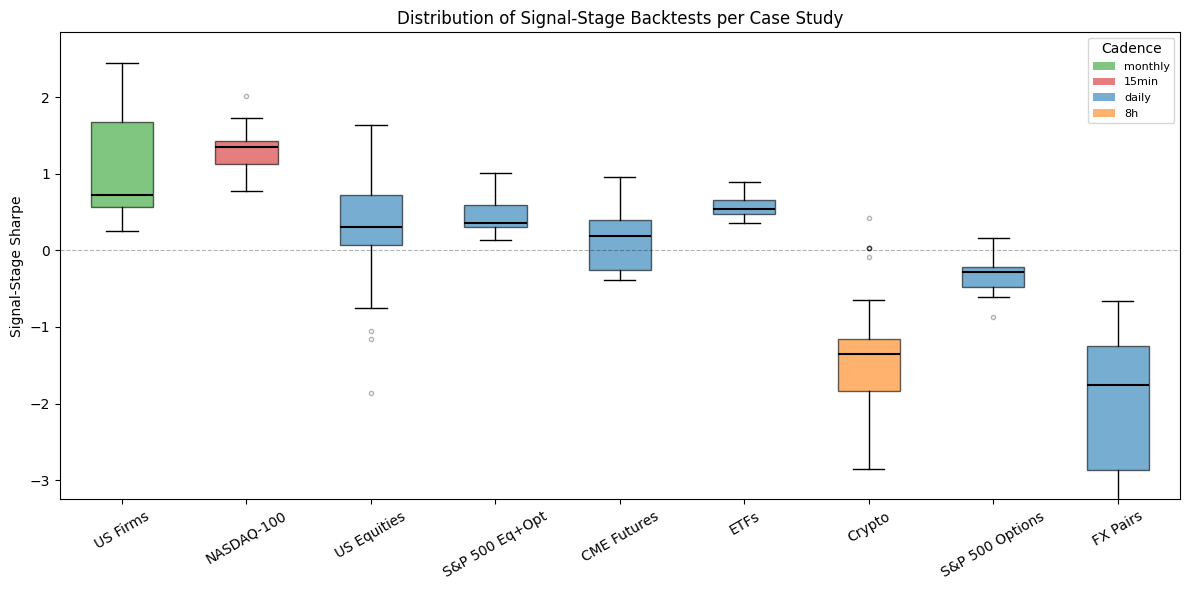

In [13]:
cadence_colors = {
    "15min": "#d62728",
    "8h": "#ff7f0e",
    "daily": "#1f77b4",
    "monthly": "#2ca02c",
}

cs_order = (
    variant_df.filter(pl.col("sharpe").is_not_null())
    .group_by("case_study")
    .agg(best=pl.col("sharpe").max())
    .sort("best", descending=True)["case_study"]
    .to_list()
)

cs_sharpes = []
cs_labels = []
cs_colors_list = []
for cs_name in cs_order:
    sub = variant_df.filter((pl.col("case_study") == cs_name) & pl.col("sharpe").is_not_null())
    if sub.is_empty():
        continue
    cs_sharpes.append(sub["sharpe"].to_numpy())
    cs_labels.append(cs_name)
    cs_colors_list.append(cadence_colors.get(sub["cadence"][0], "gray"))

fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(
    cs_sharpes,
    tick_labels=cs_labels,
    vert=True,
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 1.5},
    flierprops={"markersize": 3, "alpha": 0.3},
)
for patch, color in zip(bp["boxes"], cs_colors_list, strict=False):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.3)
ax.set_ylabel("Signal-Stage Sharpe")
ax.set_title("Distribution of Signal-Stage Backtests per Case Study")
ax.tick_params(axis="x", rotation=30)

cs_medians = np.array([np.median(s) for s in cs_sharpes]) if cs_sharpes else np.array([0.0])
all_sharpes = np.concatenate(cs_sharpes) if cs_sharpes else np.array([0.0])
y_lo = float(min(cs_medians.min() - 1.5, np.quantile(all_sharpes, 0.10) - 0.2))
y_hi = float(max(cs_medians.max() + 1.5, np.quantile(all_sharpes, 0.90) + 0.2))
ax.set_ylim(max(y_lo, -5.0), min(y_hi, 4.0))

for i, (label, sharpes) in enumerate(zip(cs_labels, cs_sharpes, strict=False), start=1):
    median = float(np.median(sharpes))
    if median < ax.get_ylim()[0]:
        ax.annotate(
            f"median {median:.1f}",
            xy=(i, ax.get_ylim()[0]),
            xytext=(0, 14),
            textcoords="offset points",
            ha="center",
            fontsize=8,
            color="#a32222",
            arrowprops={"arrowstyle": "->", "color": "#a32222", "lw": 0.6},
        )

used_cadences = list(dict.fromkeys(cs_colors_list))
color_to_cadence = {v: k for k, v in cadence_colors.items()}
handles = [
    Patch(facecolor=c, alpha=0.6, label=color_to_cadence[c])
    for c in used_cadences
    if c in color_to_cadence
]
if handles:
    ax.legend(handles=handles, loc="upper right", fontsize=8, title="Cadence")
fig.tight_layout()
fig.show()

The within-case-study spread varies widely. The widest ranges appear where
configurations span strongly negative to positive Sharpe — US Equities (−1.9 to
1.6), FX Pairs (−4.1 to −0.7), and Crypto (−2.8 to 0.4) — while case studies whose
variants are uniformly positive cluster more tightly: NASDAQ-100 runs 0.8 to 2.0,
and ETFs are tightest at 0.4 to 0.9. The dispersion within a single case study is
often as large as the differences between case studies, which is the practical
point: picking a single rank-1 configuration from dozens tested is a
multiple-testing problem that DSR is specifically designed to address.

## Variant Analysis: Positive Sharpe Rate

What fraction of model variants produce positive signal-stage Sharpe?

In [14]:
variant_stats = (
    variant_df.group_by("case_study")
    .agg(
        n_variants=pl.len(),
        n_positive=pl.col("positive_sharpe").sum(),
        pct_positive=(pl.col("positive_sharpe").sum() / pl.len() * 100).round(1),
        best_sharpe=pl.col("sharpe").max(),
    )
    .sort("pct_positive", descending=True)
)

### Positive Sharpe Rate by Case Study

In [15]:
variant_stats

case_study,n_variants,n_positive,pct_positive,best_sharpe
str,u32,u32,f64,f64
"""US Firms""",50,50,100.0,2.44396
"""NASDAQ-100""",31,31,100.0,2.019224
"""ETFs""",55,55,100.0,0.887831
"""S&P 500 Eq+Opt""",54,54,100.0,1.006782
"""US Equities""",35,29,82.9,1.641513
"""CME Futures""",50,31,62.0,0.956424
"""Crypto""",49,5,10.2,0.427879
"""S&P 500 Options""",50,4,8.0,0.15982
"""FX Pairs""",49,0,0.0,-0.667517


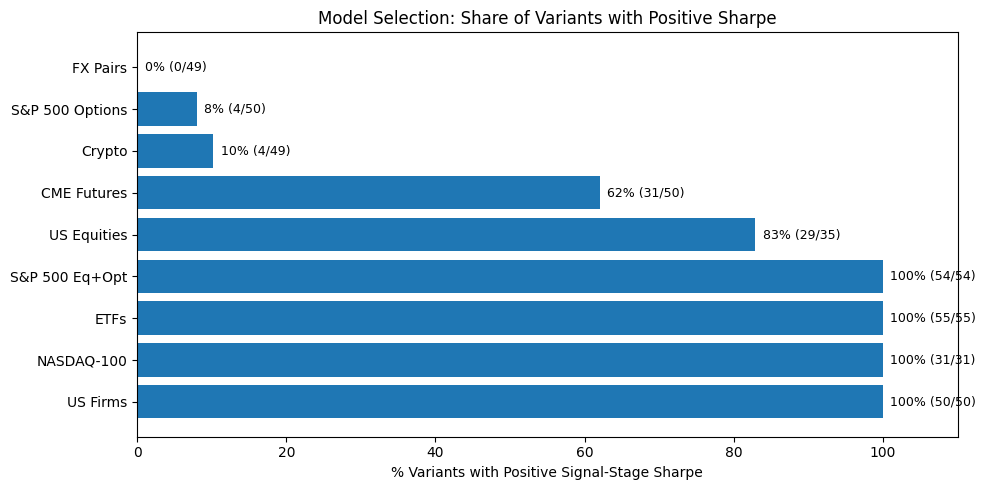

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

cs_list = variant_stats["case_study"].to_list()
pct_list = variant_stats["pct_positive"].to_list()
n_list = variant_stats["n_variants"].to_list()

bars = ax.barh(cs_list, pct_list)
ax.set_xlabel("% Variants with Positive Signal-Stage Sharpe")
ax.set_title("Model Selection: Share of Variants with Positive Sharpe")
ax.set_xlim(0, 110)
for i, (pct, n) in enumerate(zip(pct_list, n_list, strict=False)):
    ax.text(pct + 1, i, f"{pct:.0f}% ({int(pct * n / 100)}/{n})", va="center", fontsize=9)

fig.tight_layout()
fig.show()

## Signal Threshold Sweep

How does selectivity (top N% of assets) affect portfolio Sharpe?

In [17]:
if len(sweep_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    sweep_pd = sweep_df.to_pandas()
    cs_list = sweep_pd["case_study"].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(cs_list)))

    for i, cs in enumerate(cs_list):
        mask = sweep_pd["case_study"] == cs
        sub = sweep_pd[mask].sort_values("percentile")
        axes[0].plot(
            100 - sub["percentile"], sub["sharpe"], "o-", color=colors[i], label=cs, markersize=5
        )
        axes[1].plot(
            100 - sub["percentile"],
            sub["n_positions"],
            "o-",
            color=colors[i],
            label=cs,
            markersize=5,
        )

    axes[0].set_xlabel("Selectivity (top N%)")
    axes[0].set_ylabel("Sharpe Ratio")
    axes[0].set_title("Sharpe vs Selectivity")
    axes[0].legend(fontsize=7, ncol=2)
    axes[0].invert_xaxis()

    axes[1].set_xlabel("Selectivity (top N%)")
    axes[1].set_ylabel("Average Positions")
    axes[1].set_title("Position Count vs Selectivity")
    axes[1].invert_xaxis()

    fig.tight_layout()
    fig.show()
else:
    print("No signal sweep data available")

No signal sweep data available


## Key Takeaways

1. **IC does not linearly map to Sharpe.** The correlation is positive but
   noisy, mediated by costs, universe size, and holding period.
2. **The highest-IC family is rarely the highest-Sharpe family.** In the
   majority of case studies the family with the highest mean IC is not
   the family with the highest backtest Sharpe; the implementation
   pipeline mediates between the two.
3. **Label design is a first-order decision.** Case studies where the
   highest-IC family is not the highest-Sharpe family (ETFs, Crypto,
   NASDAQ-100, S&P 500 Eq+Opt, FX Pairs, CME Futures, S&P 500 Options —
   seven of nine) show that *what you predict* matters as much as
   *how you predict it*.
4. **DSR significance is bimodal.** Some case studies pass all variants,
   others pass none, indicating DSR is more sensitive to the number of
   tested models than to gradual filtering.

**Next**: [`05_portfolio_allocation`](05_portfolio_allocation.ipynb)
compares allocator choices across the case studies;
[`06_cost_survival`](06_cost_survival.ipynb) then analyzes which
strategies survive realistic costs.